# Assignment 1. Digital Signal Processing

## 1. Implement a PyTorch layer (inherit a class from torch.nn.Module) for extraction of logarithms of Mel-scale Filterbank energies using basic torch math operations

In [1]:
from typing import Optional

import torch
from torch import nn
from torchaudio import functional as F


class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        # general params and params defined by the exercise
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        # self.window = torch.hann_window(self.window_length)
        self.register_buffer('window', torch.hann_window(self.window_length))
        # Do correct initialization of stft params below:
        # hop_length, n_mels, center, return_complex, onesided, normalize_stft, pad_mode, power
        # ...
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power

        # Do correct initialization of mel fbanks params below:
        # f_min_hz, f_max_hz, norm_mel, mel_scale
        # ...
        self.f_min_hz = f_min_hz
        self.f_max_hz = f_max_hz if f_max_hz is not None else float(samplerate // 2)
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale
        self.eps = 1e-6

        # finish parameters initialization
        self.register_buffer('mel_fbanks', self._init_melscale_fbanks())

    def _init_melscale_fbanks(self):
        # To access attributes, use self.<parameter_name>
        return F.melscale_fbanks(
            # Turns a normal STFT into a mel frequency STFT with triangular filter banks
            # make a full and correct function call
            n_freqs = self.n_fft // 2 + 1,
            f_min = self.f_min_hz,
            f_max = self.f_max_hz,
            n_mels = self.n_mels,
            sample_rate = self.samplerate,
            norm = self.norm_mel,
            mel_scale = self.mel_scale
        )

    def spectrogram(self, x):
        # x - is an input signal
        return torch.stft(
            # make a full and correct function call
            input=x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.window_length,
            window=self.window.to(x.device),
            center=self.center,
            pad_mode=self.pad_mode,
            normalized=self.normalize_stft,
            onesided=self.onesided,
            return_complex=self.return_complex
        )

    def forward(self, x):
        """
        Args:
            x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
        Returns:
            Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
                where n_frames is a function of the window_length, hop_length and length of audio
        """
        spectrogram = self.spectrogram(x)
        power_spectrogram = torch.pow(torch.abs(spectrogram), self.power)
        mel_spectrogram = torch.matmul(power_spectrogram.transpose(-1,-2), self.mel_fbanks).transpose(-1, -2)
        log_mel_spectrogram = torch.log(mel_spectrogram + self.eps)
        # Return log mel filterbanks matrix
        return log_mel_spectrogram

### Evaluation

In [2]:
from google import colab
colab.drive.mount('/content/drive')

Mounted at /content/drive


Implementation match: True


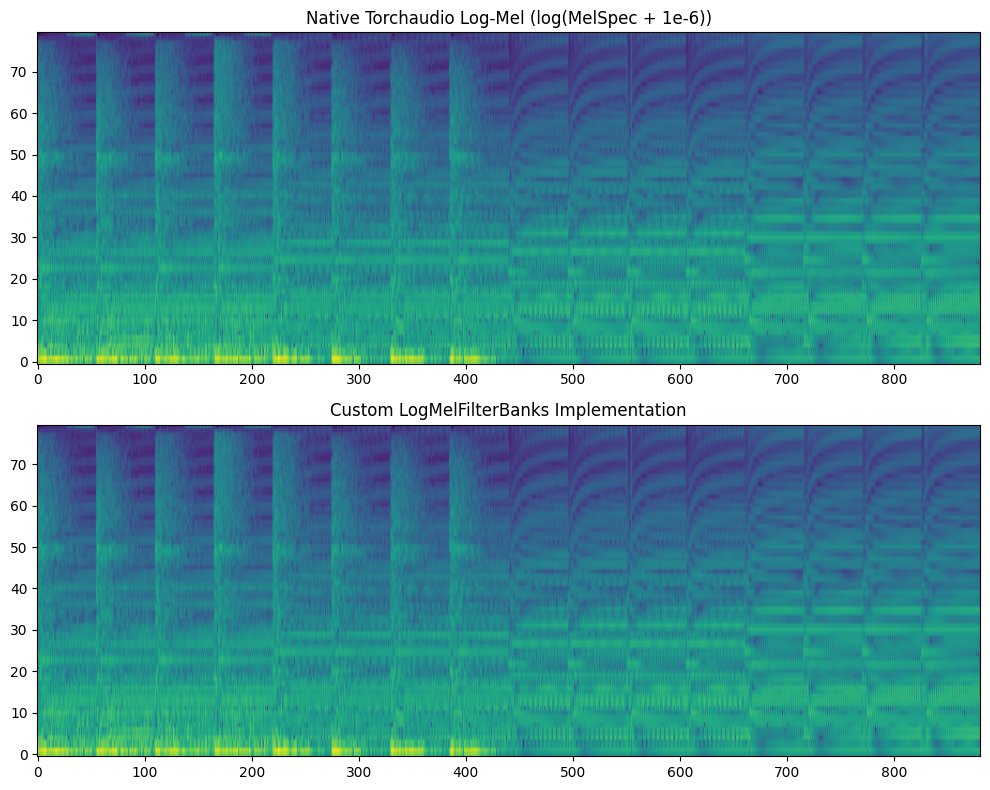

In [3]:
import torch
import torchaudio
import matplotlib.pyplot as plt

wav_path = "/content/drive/MyDrive/ITMO/Courses/ASR_TTS/Assignment_1/sample-3s.wav"
signal, sr = torchaudio.load(wav_path)


melspec_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    hop_length=160,
    n_mels=80,
    center=True,
    power=2.0
)
ref_melspec = melspec_transform(signal)
ref_logmel = torch.log(ref_melspec + 1e-6)

# Custom implementation
custom_layer = LogMelFilterBanks(n_fft=400, hop_length=160, n_mels=80)
custom_logmel = custom_layer(signal)

assert ref_logmel.shape == custom_logmel.shape
is_close = torch.allclose(ref_logmel, custom_logmel)
print(f"Implementation match: {is_close}")


fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].imshow(ref_logmel[0].detach().numpy(), aspect='auto', origin='lower')
ax[0].set_title("Native Torchaudio Log-Mel (log(MelSpec + 1e-6))")
ax[1].imshow(custom_logmel[0].detach().numpy(), aspect='auto', origin='lower')
ax[1].set_title("Custom LogMelFilterBanks Implementation")
plt.tight_layout()
plt.show()

## 2. Train a simple CNN model (no more than 100K parameters) with LogMelFilterBanks features for a binary classification problem with PyTorch on Google Speech Commands data

In [4]:
!pip install thop

### Data preparation

In [6]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as nnF
from torch.utils.data import Dataset, DataLoader
from torchaudio.datasets import SPEECHCOMMANDS
import matplotlib.pyplot as plt
from thop import profile
import tqdm


class BinarySpeechCommands(Dataset):
    def __init__(self, subset="training"):
        self.dataset = SPEECHCOMMANDS(root="./", subset=subset, download=True)
        self.data = []

        valid_labels = {'no': 0, 'yes': 1}

        for item in self.dataset:
            waveform, sample_rate, label, speaker_id, utterance_number = item
            if label in valid_labels:
                if waveform.shape[1] < sample_rate:
                    pad_length = sample_rate - waveform.shape[1]
                    waveform = nnF.pad(waveform, (0, pad_length))
                self.data.append((waveform, valid_labels[label]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

print("Data preparation...")
train_dataset = BinarySpeechCommands(subset="training")
val_dataset = BinarySpeechCommands(subset="validation")
test_dataset = BinarySpeechCommands(subset="testing")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)
print(f"Sample sizes - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Data preparation...
Sample sizes - Train: 6358, Val: 803, Test: 824


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### CNN model

In [9]:
class SimpleSpeechCNN(nn.Module):
    def __init__(self, n_mels=80, groups=1):
        super(SimpleSpeechCNN, self).__init__()
        # from first task
        self.melspec = LogMelFilterBanks(n_mels=n_mels)

        # 1D CNN
        self.conv1 = nn.Conv1d(in_channels=n_mels, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)

        # groups for experiments
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1, groups=groups)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=3, padding=1, groups=groups)
        self.bn3 = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(2)
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)

        # binary classification
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: (batch_size, 1, 16000)
        x = x.squeeze(1)

        # (batch, n_mels, time_frames)
        x = self.melspec(x)

        x = self.pool(nnF.relu(self.bn1(self.conv1(x))))
        x = self.pool(nnF.relu(self.bn2(self.conv2(x))))
        x = nnF.relu(self.bn3(self.conv3(x)))

        x = self.adaptive_pool(x).squeeze(-1) # Global Average Pooling
        x = self.fc(x)
        return x

def train_model(model, train_loader, val_loader, epochs=5, device='cuda'):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    history = {'train_loss': [], 'val_acc': [], 'epoch_time': []}

    for epoch in range(epochs):
        start_time = time.time()

        # Train
        model.train()
        train_loss = 0.0
        for waveforms, labels in train_loader:
            waveforms, labels = waveforms.to(device), labels.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(waveforms)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * waveforms.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        correct = 0
        with torch.no_grad():
            for waveforms, labels in val_loader:
                waveforms, labels = waveforms.to(device), labels.to(device)
                outputs = model(waveforms).squeeze(1)
                preds = (torch.sigmoid(outputs) > 0.5).long()
                correct += (preds == labels).sum().item()

        val_acc = correct / len(val_loader.dataset)
        epoch_time = time.time() - start_time

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")

    return history

def test_model(model, test_loader, device='cuda'):
    model.eval()
    correct = 0
    with torch.no_grad():
        for waveforms, labels in test_loader:
            waveforms, labels = waveforms.to(device), labels.to(device)
            outputs = model(waveforms).squeeze(1)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            correct += (preds == labels).sum().item()
    return correct / len(test_loader.dataset)

def get_params_and_flops(model, input_shape=(1, 1, 16000), device='cuda'):
    dummy_input = torch.randn(input_shape).to(device)
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    flops = macs * 2 # 1 MAC = 2 FLOPs (оценочно)
    return params, flops

## Experiment with `n_mels`

=== Experiment with n_mels ===

Model train with n_mels = 20
Params: 20.9K | FLOPs: 1.7M


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/5 | Loss: 0.2548 | Val Acc: 0.9539 | Time: 2.22s
Epoch 2/5 | Loss: 0.1266 | Val Acc: 0.9701 | Time: 2.01s
Epoch 3/5 | Loss: 0.0906 | Val Acc: 0.9776 | Time: 1.81s
Epoch 4/5 | Loss: 0.0721 | Val Acc: 0.9875 | Time: 1.34s
Epoch 5/5 | Loss: 0.0601 | Val Acc: 0.9763 | Time: 1.29s
Test Accuracy for n_mels=20: 0.9806

Model train with n_mels = 40
Params: 22.8K | FLOPs: 2.1M
Epoch 1/5 | Loss: 0.2644 | Val Acc: 0.9701 | Time: 1.31s
Epoch 2/5 | Loss: 0.1236 | Val Acc: 0.9776 | Time: 1.32s
Epoch 3/5 | Loss: 0.0857 | Val Acc: 0.9788 | Time: 1.29s
Epoch 4/5 | Loss: 0.0662 | Val Acc: 0.9215 | Time: 1.41s
Epoch 5/5 | Loss: 0.0526 | Val Acc: 0.9900 | Time: 1.40s
Test Accuracy for n_mels=40: 0.9830

Model train with n_mels = 80
Params: 26.7K | FLOPs: 2.8M
Epoch 1/5 | Loss: 0.2761 | Val Acc: 0.9502 | Time: 2.11s
Epoch 2/5 | Loss: 0.1429 | Val Acc: 0.9714 | Time: 1.87s
Epoch 3/5 | Loss: 0.0928 | Val Acc: 0.9303 | Time: 1.30s
Epoch 4/5 | Loss: 0.0666 | Val Acc: 0.9614 | Time: 1.31s
Epoch 5/5 | Lo

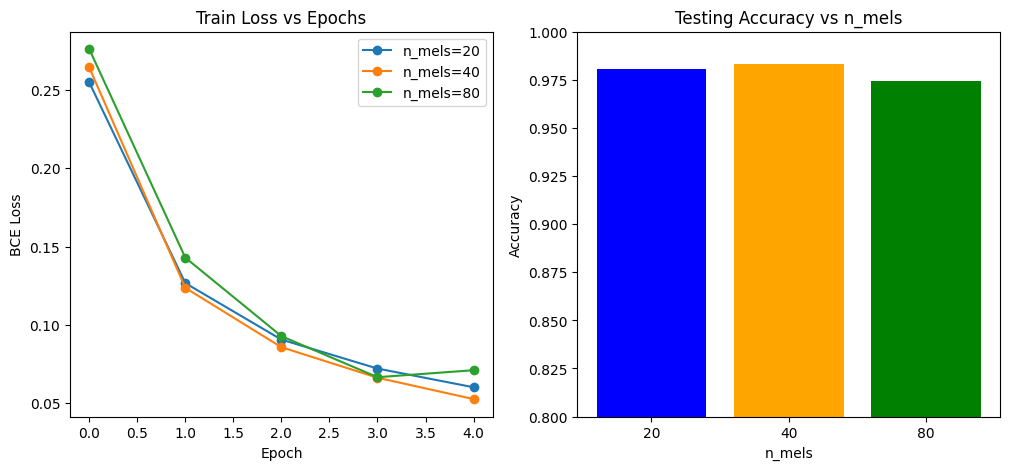

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_mels_list = [20, 40, 80]
mels_results = {}

print("=== Experiment with n_mels ===")
for mels in n_mels_list:
    print(f"\nModel train with n_mels = {mels}")
    model = SimpleSpeechCNN(n_mels=mels, groups=1).to(device)

    # Measurement of parameters and FLOPs
    params, flops = get_params_and_flops(model)
    print(f"Params: {params/1000:.1f}K | FLOPs: {flops/1e6:.1f}M")

    history = train_model(model, train_loader, val_loader, epochs=5, device=device)
    test_acc = test_model(model, test_loader, device=device)

    mels_results[mels] = {
        'history': history,
        'test_acc': test_acc
    }
    print(f"Test Accuracy for n_mels={mels}: {test_acc:.4f}")

# Plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for mels, res in mels_results.items():
    plt.plot(res['history']['train_loss'], label=f'n_mels={mels}', marker='o')
plt.title('Train Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

plt.subplot(1, 2, 2)
mels_vals = list(mels_results.keys())
acc_vals = [res['test_acc'] for res in mels_results.values()]
plt.bar([str(m) for m in mels_vals], acc_vals, color=['blue', 'orange', 'green'])
plt.title('Testing Accuracy vs n_mels')
plt.xlabel('n_mels')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.show()

## Experiment with `groups`

=== Experiment with groups ===

Model train with groups = 1
Epoch 1/5 | Loss: 0.2632 | Val Acc: 0.9514 | Time: 1.43s
Epoch 2/5 | Loss: 0.1271 | Val Acc: 0.9763 | Time: 1.29s
Epoch 3/5 | Loss: 0.0886 | Val Acc: 0.9838 | Time: 1.28s
Epoch 4/5 | Loss: 0.0624 | Val Acc: 0.9776 | Time: 1.30s
Epoch 5/5 | Loss: 0.0598 | Val Acc: 0.9851 | Time: 1.29s

Model train with groups = 2
Epoch 1/5 | Loss: 0.3038 | Val Acc: 0.9489 | Time: 1.42s
Epoch 2/5 | Loss: 0.1525 | Val Acc: 0.9626 | Time: 1.34s
Epoch 3/5 | Loss: 0.1127 | Val Acc: 0.9714 | Time: 1.53s
Epoch 4/5 | Loss: 0.0794 | Val Acc: 0.9813 | Time: 2.11s
Epoch 5/5 | Loss: 0.0620 | Val Acc: 0.9738 | Time: 1.87s

Model train with groups = 4
Epoch 1/5 | Loss: 0.3349 | Val Acc: 0.9427 | Time: 1.39s
Epoch 2/5 | Loss: 0.1634 | Val Acc: 0.9614 | Time: 1.30s
Epoch 3/5 | Loss: 0.1103 | Val Acc: 0.9564 | Time: 1.31s
Epoch 4/5 | Loss: 0.0876 | Val Acc: 0.9763 | Time: 1.33s
Epoch 5/5 | Loss: 0.0710 | Val Acc: 0.9726 | Time: 1.34s

Model train with groups = 

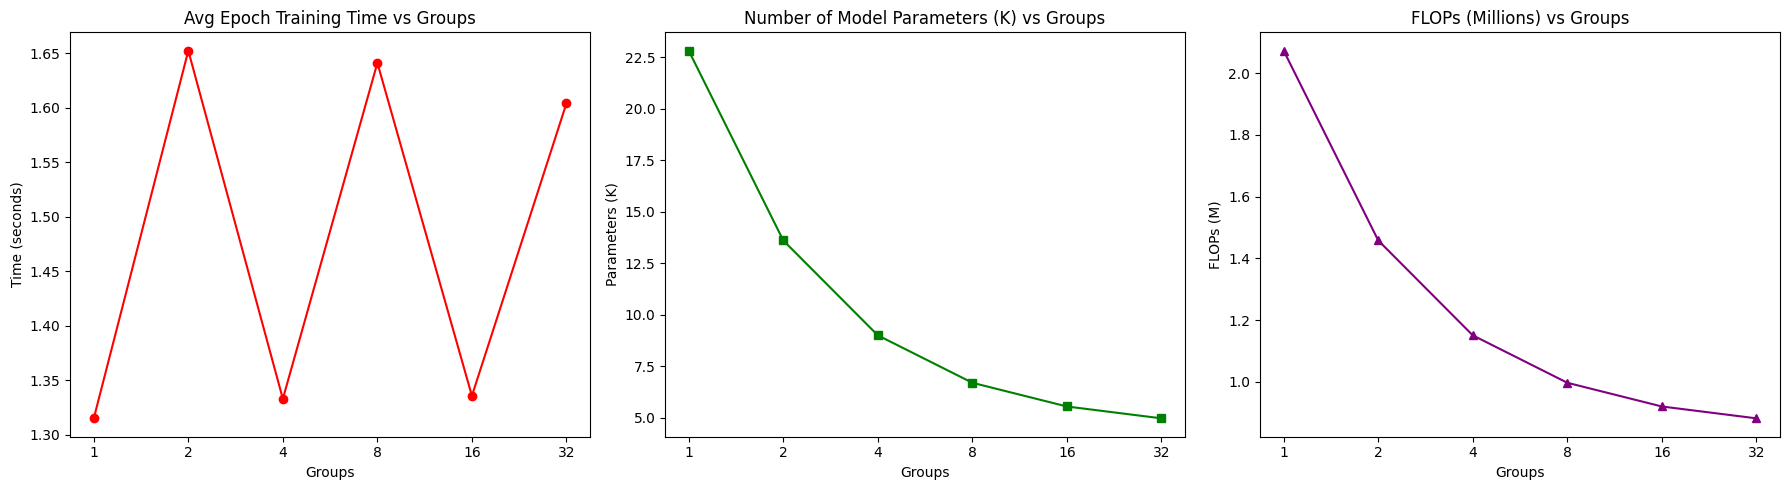

In [11]:
groups_list = [1, 2, 4, 8, 16, 32]
baseline_n_mels = 40

groups_results = {}

print("=== Experiment with groups ===")
for g in groups_list:
    print(f"\nModel train with groups = {g}")
    model = SimpleSpeechCNN(n_mels=baseline_n_mels, groups=g).to(device)

    params, flops = get_params_and_flops(model)
    history = train_model(model, train_loader, val_loader, epochs=5, device=device)

    avg_epoch_time = sum(history['epoch_time']) / len(history['epoch_time'])

    groups_results[g] = {
        'params': params,
        'flops': flops,
        'avg_epoch_time': avg_epoch_time,
        'val_acc': history['val_acc'][-1]
    }

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

groups_keys = [str(g) for g in groups_list]

# Time vs Groups
times = [groups_results[g]['avg_epoch_time'] for g in groups_list]
axes[0].plot(groups_keys, times, marker='o', color='red')
axes[0].set_title('Avg Epoch Training Time vs Groups')
axes[0].set_xlabel('Groups')
axes[0].set_ylabel('Time (seconds)')

# Params vs Groups
params = [groups_results[g]['params']/1000 for g in groups_list]
axes[1].plot(groups_keys, params, marker='s', color='green')
axes[1].set_title('Number of Model Parameters (K) vs Groups')
axes[1].set_xlabel('Groups')
axes[1].set_ylabel('Parameters (K)')

# FLOPs vs Groups
flops = [groups_results[g]['flops']/1e6 for g in groups_list]
axes[2].plot(groups_keys, flops, marker='^', color='purple')
axes[2].set_title('FLOPs (Millions) vs Groups')
axes[2].set_xlabel('Groups')
axes[2].set_ylabel('FLOPs (M)')

plt.tight_layout()
plt.show()

# Task report: Digital Signal Processing & CNN Training

## 1. Извлечение признаков (Log Mel-scale Filterbank)

Был реализован кастомный слой `LogMelFilterBanks` на чистом PyTorch для извлечения логарифмов энергий мел-спектрограммы. Результат работы кастомного слоя был успешно сверен с нативной реализацией `torchaudio.transforms.MelSpectrogram` (с добавлением логарифмирования). Различий в тензорах не выявлено.

---

## 2. Эксперимент с количеством мел-фильтров (`n_mels`)

Для бинарной классификации датасета Speech Commands ("yes" / "no") была построена простая сверточная нейронная сеть (1D CNN). В первом эксперименте варьировался параметр `n_mels` (количество фильтров в мел-спектрограмме) для оценки его влияния на размер модели, вычислительную сложность и точность.

**Результаты эксперимента:**

| `n_mels` | Params (Кол-во параметров) | FLOPs (Вычислит. сложность) | Test Accuracy (Точность на тесте) |
| --- | --- | --- | --- |
| 20 | 20.9K | 1.7M | 0.9806 (98.06%) |
| **40** | **22.8K** | **2.1M** | **0.9830 (98.30%)** |
| 80 | 26.7K | 2.8M | 0.9745 (97.45%) |

**Выводы:**

* **Размер и сложность:** С увеличением `n_mels` линейно возрастает количество параметров модели (от 20.9K до 26.7K) и количество математических операций (FLOPs). Это логично, так как увеличивается размерность входного тензора для первого сверточного слоя.
* **Качество (Accuracy):** Наилучший результат показала модель с `n_mels = 40` (98.30%). Использование всего 20 фильтров дает хорошую точность, но, вероятно, теряет часть важных частотных деталей. Переход к 80 фильтрам привел к небольшому падению точности (до 97.45%). Это может быть связано с тем, что для небольшой модели (менее 30К параметров) слишком высокое разрешение входных признаков приводит к переобучению (overfitting) или модель не обладает достаточной емкостью, чтобы эффективно обработать такое количество каналов.
* **Бейзлайн:** Для следующего эксперимента в качестве оптимального бейзлайна была выбрана модель с `n_mels = 40`.

---

## 3. Эксперимент с групповыми свертками (`groups`)

В данном эксперименте параметр `groups` в слоях `Conv1d` изменялся в диапазоне `{1, 2, 4, 8, 16, 32}`. Базовая размерность признаков `n_mels = 40`.

**Результаты эксперимента (метрики на 5-й эпохе):**

| `groups` | Train Loss | Validation Accuracy | Среднее время эпохи |
| --- | --- | --- | --- |
| 1 | 0.0598 | 98.51% | ~1.32s |
| 2 | 0.0620 | 97.38% | ~1.65s |
| 4 | 0.0710 | 97.26% | ~1.33s |
| 8 | 0.0889 | 97.26% | ~1.64s |
| 16 | 0.0999 | 97.38% | ~1.34s |
| 32 | 0.1222 | 95.77% | ~1.60s |


**Выводы:**

* **Влияние на Loss и Accuracy:** Как видно из данных, при увеличении значения `groups` обучающий Loss (ошибка) постепенно возрастает (с 0.0598 до 0.1222), а точность на валидации падает (с 98.51% до 95.77% при `groups=32`). Это подтверждает теорию: при групповых свертках фильтры "видят" только часть входных каналов, из-за чего теряются межканальные взаимосвязи, что снижает выразительную способность (expressiveness) модели.
* **Время обучения:** Несмотря на значительное теоретическое снижение FLOPs , время выполнения одной эпохи не уменьшилось, а в некоторых случаях даже немного колебалось в большую сторону (от 1.3s до 2.1s).
* **Причины отсутствия ускорения:** Это объясняется тем, что наша модель *экстремально маленькая* (всего ~20K параметров). Для современных GPU расчет такой сети происходит практически мгновенно, и узким местом становится не математика, а накладные расходы фреймворка: пересылка данных, запуск CUDA-ядер и загрузка данных DataLoader-ом. Таким образом, для очень маленьких моделей групповые свертки не дают выигрыша во времени на GPU, но отлично подходят для сжатия размера сети при деплое на слабые устройства.
